# A Practical Study of Stable Diffusion for Image Generation and Editing

## Notebook 01: Text-to-Image Generation Experiments

This notebook conducts controlled experiments on text-to-image generation using Stable Diffusion.  
The experiments analyze how inference steps and guidance scale affect image quality, prompt alignment, and generation time.

In [1]:
!pip install -U diffusers transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 90.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.0
    Uninstalling transformers-5.12.0:
      Successfully uninstalled transformers-5.12.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#加载库
import os
import time
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
#加载模型
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to("cuda")

pipe.enable_attention_slicing()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [ ]:
import os
prompt = "a cozy cafe interior by the window, a wooden table with a cup of coffee and an open book, soft morning light, realistic photo, detailed background"

seed = 42
guidance_scale = 7.5
height = 512
width = 512

base_output_dir = "/content/drive/MyDrive/Diffusion科研学习/outputs"
os.makedirs(base_output_dir, exist_ok=True)
print("Output directory:", base_output_dir)

Output directory: /content/drive/MyDrive/Diffusion科研学习/outputs


In [ ]:
import time
import torch
import os

exp_dir = os.path.join(base_output_dir, "exp1_steps_main_cafe")
os.makedirs(exp_dir, exist_ok=True)

steps_list = [10, 15, 30, 50]
results = []

# ===== Warm-up：预热，不记录时间 =====
print("Warm-up running...")

_ = pipe(
    prompt,
    num_inference_steps=10,
    guidance_scale=guidance_scale,
    height=height,
    width=width,
    generator=torch.Generator("cuda").manual_seed(seed)
).images[0]

torch.cuda.synchronize()
print("Warm-up finished.")

# ===== 正式实验：每个 steps 跑 3 次，取平均 =====
for steps in steps_list:
    times = []
    last_image = None

    print(f"\nRunning steps = {steps}")

    for run in range(3):
        generator = torch.Generator("cuda").manual_seed(seed)

        torch.cuda.synchronize()
        start = time.time()

        image = pipe(
            prompt,
            num_inference_steps=steps,
            guidance_scale=guidance_scale,
            height=height,
            width=width,
            generator=generator
        ).images[0]

        torch.cuda.synchronize()
        end = time.time()

        elapsed = end - start
        times.append(elapsed)
        last_image = image

        print(f"  Run {run + 1}: {elapsed:.2f} sec")

    avg_time = sum(times) / len(times)

    # 只保存最后一次生成的图片，避免同一个 steps 保存三张
    save_path = os.path.join(exp_dir, f"steps_{steps}.png")
    last_image.save(save_path)

    results.append({
        "prompt": prompt,
        "steps": steps,
        "avg_time_sec": round(avg_time, 2),
        "all_runs_sec": [round(t, 2) for t in times],
        "file": save_path
    })

results

Warm-up running...


  0%|          | 0/10 [00:00<?, ?it/s]

Warm-up finished.

Running steps = 10


  0%|          | 0/10 [00:00<?, ?it/s]

  Run 1: 3.26 sec


...

  0%|          | 0/50 [00:00<?, ?it/s]

  Run 2: 12.28 sec


  0%|          | 0/50 [00:00<?, ?it/s]

  Run 3: 12.71 sec


[{'prompt': 'a cozy cafe interior by the window, a wooden table with a cup of coffee and an open book, soft morning light, realistic photo, detailed background',
  'steps': 10,
  'avg_time_sec': 3.35,
  'all_runs_sec': [3.26, 3.39, 3.4],
  'file': '/content/drive/MyDrive/Diffusion科研学习/outputs/exp1_steps_main_cafe/steps_10.png'},
 {'prompt': 'a cozy cafe interior by the window, a wooden table with a cup of coffee and an open book, soft morning light, realistic photo, detailed background',
  'steps': 15,
  'avg_time_sec': 4.47,
  'all_runs_sec': [4.68, 4.45, 4.27],
  'file': '/content/drive/MyDrive/Diffusion科研学习/outputs/exp1_steps_main_cafe/steps_15.png'},
 {'prompt': 'a cozy cafe interior by the window, a wooden table with a cup of coffee and an open book, soft morning light, realistic photo, detailed background',
  'steps': 30,
  'avg_time_sec': 7.52,
  'all_runs_sec': [7.68, 7.48, 7.38],
  'file': '/content/drive/MyDrive/Diffusion科研学习/outputs/exp1_steps_main_cafe/steps_30.png'},
 {'pr

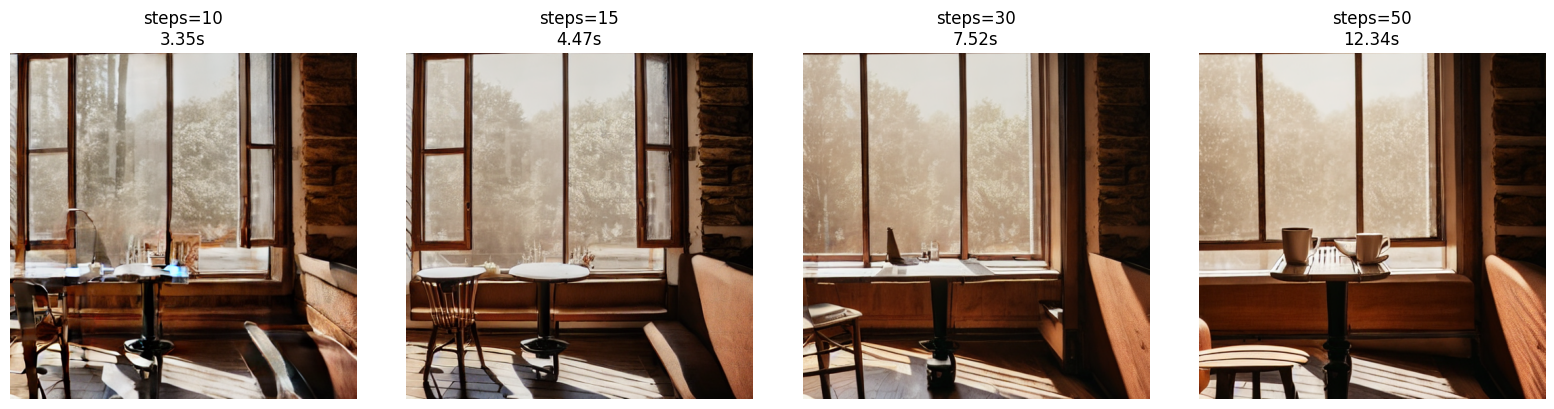

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(results), figsize=(16, 4))

for ax, item in zip(axes, results):
    img = Image.open(item["file"])
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"steps={item['steps']}\n{item['avg_time_sec']}s")

plt.tight_layout()
plt.show()

In [ ]:
import json

with open(os.path.join(exp_dir, "results.json"), "w") as f:
    json.dump(results, f, indent=4)

print("Saved results.json")

Saved results.json


## Experiment 2: Effect of guidance_scale

In [5]:
import os
import time
import torch
from PIL import Image
import matplotlib.pyplot as plt

# ===== Experiment 2: Effect of Guidance Scale =====

prompt = "a cozy cafe interior by the window, a wooden table with a cup of coffee and an open book, soft morning light, realistic photo, detailed background"

seed = 42
num_inference_steps = 30
height = 512
width = 512

# 只改变 guidance_scale
guidance_list = [3, 5, 7.5, 10, 15]

base_output_dir = "/content/drive/MyDrive/Diffusion科研学习/outputs"
exp_output_dir = os.path.join(base_output_dir, "exp2_guidance_scale_main_cafe")
os.makedirs(exp_output_dir, exist_ok=True)

print("Output directory:", exp_output_dir)

Output directory: /content/drive/MyDrive/Diffusion科研学习/outputs/exp2_guidance_scale_main_cafe


In [6]:
results_exp2 = []

# ===== Warm-up：预热，不记录时间 =====
print("Warm-up running...")

_ = pipe(
    prompt,
    num_inference_steps=num_inference_steps,
    guidance_scale=7.5,
    height=height,
    width=width,
    generator=torch.Generator("cuda").manual_seed(seed)
).images[0]

torch.cuda.synchronize()
print("Warm-up finished.")

# ===== 正式实验：每个 guidance_scale 跑 3 次 =====
for guidance_scale in guidance_list:
    times = []
    last_image = None

    print(f"\nRunning guidance_scale = {guidance_scale}")

    for run in range(3):
        generator = torch.Generator("cuda").manual_seed(seed)

        torch.cuda.synchronize()
        start = time.time()

        image = pipe(
            prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            height=height,
            width=width,
            generator=generator
        ).images[0]

        torch.cuda.synchronize()
        end = time.time()

        elapsed = end - start
        times.append(elapsed)
        last_image = image

        print(f"  Run {run + 1}: {elapsed:.2f} sec")

    avg_time = sum(times) / len(times)

    # 文件名里不要直接用 7.5，改成 7_5 更整洁
    guidance_str = str(guidance_scale).replace(".", "_")
    save_path = os.path.join(exp_output_dir, f"guidance_{guidance_str}.png")
    last_image.save(save_path)

    results_exp2.append({
        "prompt": prompt,
        "guidance_scale": guidance_scale,
        "steps": num_inference_steps,
        "avg_time_sec": round(avg_time, 2),
        "all_runs_sec": [round(t, 2) for t in times],
        "file": save_path
    })

results_exp2

Warm-up running...


  0%|          | 0/30 [00:00<?, ?it/s]

Warm-up finished.

Running guidance_scale = 3


  0%|          | 0/30 [00:00<?, ?it/s]

  Run 1: 6.64 sec


...

  0%|          | 0/30 [00:00<?, ?it/s]

  Run 2: 7.59 sec


  0%|          | 0/30 [00:00<?, ?it/s]

  Run 3: 7.55 sec


[{'prompt': 'a cozy cafe interior by the window, a wooden table with a cup of coffee and an open book, soft morning light, realistic photo, detailed background',
  'guidance_scale': 3,
  'steps': 30,
  'avg_time_sec': 6.81,
  'all_runs_sec': [6.64, 6.83, 6.96],
  'file': '/content/drive/MyDrive/Diffusion科研学习/outputs/exp2_guidance_scale_main_cafe/guidance_3.png'},
 {'prompt': 'a cozy cafe interior by the window, a wooden table with a cup of coffee and an open book, soft morning light, realistic photo, detailed background',
  'guidance_scale': 5,
  'steps': 30,
  'avg_time_sec': 7.22,
  'all_runs_sec': [7.09, 7.19, 7.38],
  'file': '/content/drive/MyDrive/Diffusion科研学习/outputs/exp2_guidance_scale_main_cafe/guidance_5.png'},
 {'prompt': 'a cozy cafe interior by the window, a wooden table with a cup of coffee and an open book, soft morning light, realistic photo, detailed background',
  'guidance_scale': 7.5,
  'steps': 30,
  'avg_time_sec': 7.81,
  'all_runs_sec': [7.59, 7.81, 8.02],
  'f

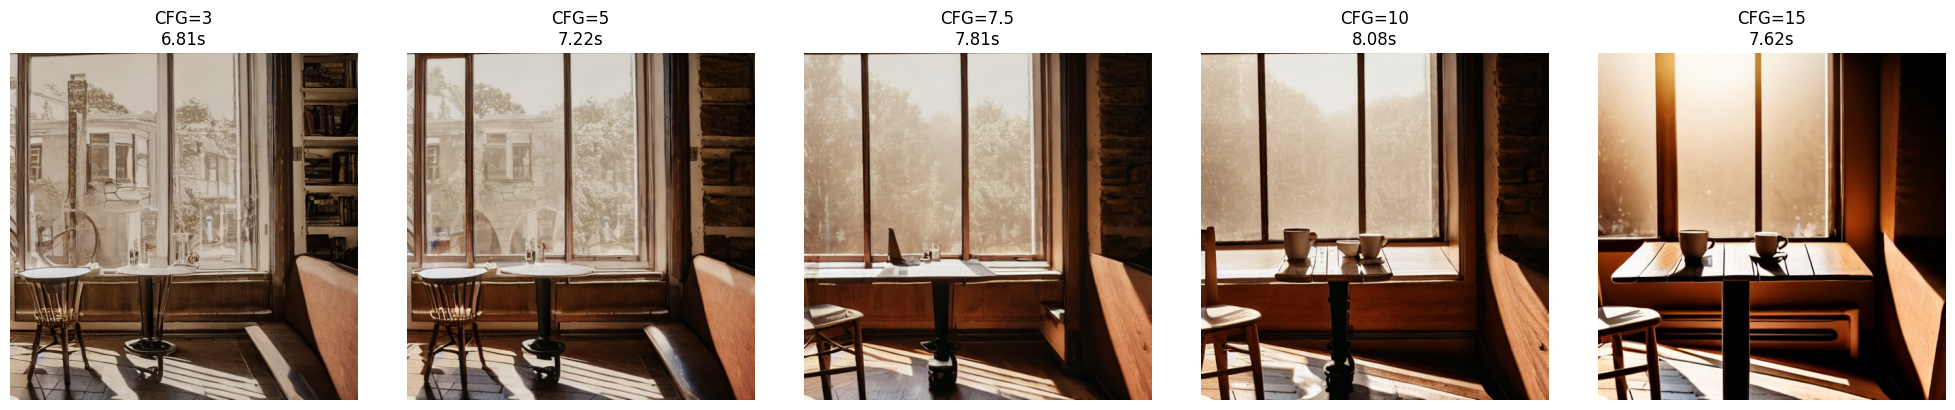

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(results_exp2), figsize=(20, 4))

for ax, item in zip(axes, results_exp2):
    img = Image.open(item["file"])
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"CFG={item['guidance_scale']}\n{item['avg_time_sec']}s")

plt.tight_layout()
plt.show()